Model imported from these weights: https://huggingface.co/keras-io/denoising-diffusion-implicit-models

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import math
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import cv2

import keras
import numpy as np
from keras import layers
from keras import ops

## Define HyperParameters Here

This part is mostly for if we wanted to train it ourselves, but some of it is needed to define the model architecture

In [ ]:
# data
dataset_name = "oxford_flowers102"
image_size = 64

# KID = Kernel Inception Distance
kid_image_size = 75
kid_diffusion_steps = 5
plot_diffusion_steps = 20

# sampling
min_signal_rate = 0.02
max_signal_rate = 0.95

# architecture
embedding_dims = 32
embedding_max_frequency = 1000.0
widths = [32, 64, 96, 128]
block_depth = 2

## Dataset Load and Preprocess

In [ ]:
def preprocess_image(data):
    # center crop image
    height = ops.shape(data["image"])[0]
    width = ops.shape(data["image"])[1]
    crop_size = ops.minimum(height, width)
    image = tf.image.crop_to_bounding_box(
        data["image"],
        (height - crop_size) // 2,
        (width - crop_size) // 2,
        crop_size,
        crop_size,
    )

    # resize and clip
    image = tf.image.resize(image, size=[image_size, image_size], antialias=True)
    return ops.clip(image / 255.0, 0.0, 1.0)


def prepare_dataset(split):
    return (
        tfds.load(dataset_name, split=split, shuffle_files=True)
        .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )

# load dataset
train_dataset = prepare_dataset("train[:80%]+validation[:80%]+test[:80%]")
val_dataset = prepare_dataset("train[80%:]+validation[80%:]+test[80%:]")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.Z5MDV3_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.Z5MDV3_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


## Kernel Inception Distance

In [ ]:
@keras.saving.register_keras_serializable()
class KID(keras.metrics.Metric):
    def __init__(self, name, **kwargs):
        super().__init__(name=name, **kwargs)

        # KID is calculated per batch and averaged across batches
        self.kid_tracker = keras.metrics.Mean(name="kid_tracker")

        # a pretrained InceptionV3 extracts features for comparison
        self.encoder = keras.Sequential(
            [
                keras.Input(shape=(image_size, image_size, 3)),
                layers.Rescaling(255.0),
                layers.Resizing(height=kid_image_size, width=kid_image_size),
                layers.Lambda(keras.applications.inception_v3.preprocess_input),
                keras.applications.InceptionV3(
                    include_top=False,
                    input_shape=(kid_image_size, kid_image_size, 3),
                    weights="imagenet",
                ),
                layers.GlobalAveragePooling2D(),
            ],
            name="inception_encoder",
        )

    # kernel for comparison
    def polynomial_kernel(self, features_1, features_2):
        feature_dimensions = ops.cast(ops.shape(features_1)[1], dtype="float32")
        return (features_1 @ ops.transpose(features_2) / feature_dimensions + 1.0) ** 3.0

    def update_state(self, real_images, generated_images, sample_weight=None):
        real_features = self.encoder(real_images, training=False)
        generated_features = self.encoder(generated_images, training=False)

        # compute polynomial kernels using the two sets of features
        kernel_real = self.polynomial_kernel(real_features, real_features)
        kernel_generated = self.polynomial_kernel(generated_features, generated_features)
        kernel_cross = self.polynomial_kernel(real_features, generated_features)

        # estimate the squared MMD using the kernel values
        batch_size = real_features.shape[0]
        batch_size_f = ops.cast(batch_size, dtype="float32")
        mean_kernel_real = ops.sum(kernel_real * (1.0 - ops.eye(batch_size))) / (batch_size_f * (batch_size_f - 1.0))
        mean_kernel_generated = ops.sum(kernel_generated * (1.0 - ops.eye(batch_size))) / (batch_size_f * (batch_size_f - 1.0))
        mean_kernel_cross = ops.mean(kernel_cross)
        kid = mean_kernel_real + mean_kernel_generated - 2.0 * mean_kernel_cross

        # update the average KID estimate
        self.kid_tracker.update_state(kid)

    def result(self):
        return self.kid_tracker.result()

    def reset_state(self):
        self.kid_tracker.reset_state()

## Model Infrastructure (run this to define the class)

In [ ]:
@keras.saving.register_keras_serializable()
def sinusoidal_embedding(x):
    embedding_min_frequency = 1.0
    frequencies = ops.exp(
        ops.linspace(
            ops.log(embedding_min_frequency),
            ops.log(embedding_max_frequency),
            embedding_dims // 2,
        )
    )
    angular_speeds = ops.cast(2.0 * math.pi * frequencies, "float32")
    embeddings = ops.concatenate(
        [ops.sin(angular_speeds * x), ops.cos(angular_speeds * x)], axis=3
    )
    return embeddings


def ResidualBlock(width):
    def apply(x):
        input_width = x.shape[3]
        if input_width == width:
            residual = x
        else:
            residual = layers.Conv2D(width, kernel_size=1)(x)
        x = layers.BatchNormalization(center=False, scale=False)(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same", activation="swish")(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same")(x)
        x = layers.Add()([x, residual])
        return x

    return apply


def DownBlock(width, block_depth):
    def apply(x):
        x, skips = x
        for _ in range(block_depth):
            x = ResidualBlock(width)(x)
            skips.append(x)
        x = layers.AveragePooling2D(pool_size=2)(x)
        return x

    return apply


def UpBlock(width, block_depth):
    def apply(x):
        x, skips = x
        x = layers.UpSampling2D(size=2, interpolation="bilinear")(x)
        for _ in range(block_depth):
            x = layers.Concatenate()([x, skips.pop()])
            x = ResidualBlock(width)(x)
        return x

    return apply


def get_network(image_size, widths, block_depth):
    noisy_images = keras.Input(shape=(image_size, image_size, 3))
    noise_variances = keras.Input(shape=(1, 1, 1))

    e = layers.Lambda(sinusoidal_embedding, output_shape=(1, 1, 32))(noise_variances)
    e = layers.UpSampling2D(size=image_size, interpolation="nearest")(e)

    x = layers.Conv2D(widths[0], kernel_size=1)(noisy_images)
    x = layers.Concatenate()([x, e])

    skips = []
    for width in widths[:-1]:
        x = DownBlock(width, block_depth)([x, skips])

    for _ in range(block_depth):
        x = ResidualBlock(widths[-1])(x)

    for width in reversed(widths[:-1]):
        x = UpBlock(width, block_depth)([x, skips])

    x = layers.Conv2D(3, kernel_size=1, kernel_initializer="zeros")(x)

    return keras.Model([noisy_images, noise_variances], x, name="residual_unet")

In [ ]:
@keras.saving.register_keras_serializable()
class DiffusionModel(keras.Model):
    def __init__(self, image_size, widths, block_depth):
        super().__init__()

        self.normalizer = layers.Normalization()
        self.network = get_network(image_size, widths, block_depth)
        self.ema_network = keras.models.clone_model(self.network)

    def call(self, inputs, training=False):
        # Inputs will be: [x_t, t_int] where t_int is a scalar timestep
        x, t = inputs

        # Normalize timestep t (int: 0–999) to diffusion_time (float: 0–1)
        diffusion_time = tf.cast(t, tf.float32) / 1000.0
        diffusion_time = tf.reshape(diffusion_time, [-1, 1, 1, 1])  # match image shape

        # Convert to noise/signal rates
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_time)

        # Predict noise using the model’s denoising pipeline
        pred_noises, _ = self.denoise(x, noise_rates, signal_rates, training=training)

        return pred_noises

    def compile(self, **kwargs):
        super().compile(**kwargs)

        self.noise_loss_tracker = keras.metrics.Mean(name="n_loss")
        self.image_loss_tracker = keras.metrics.Mean(name="i_loss")
        self.kid = KID(name="kid")

    @property
    def metrics(self):
        return [self.noise_loss_tracker, self.image_loss_tracker, self.kid]

    def denormalize(self, images):
        # convert the pixel values back to 0-1 range
        images = self.normalizer.mean + images * self.normalizer.variance**0.5
        return ops.clip(images, 0.0, 1.0)

    def diffusion_schedule(self, diffusion_times):
        # diffusion times -> angles
        start_angle = ops.cast(ops.arccos(max_signal_rate), "float32")
        end_angle = ops.cast(ops.arccos(min_signal_rate), "float32")

        diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)

        # angles -> signal and noise rates
        signal_rates = ops.cos(diffusion_angles)
        noise_rates = ops.sin(diffusion_angles)
        # note that their squared sum is always: sin^2(x) + cos^2(x) = 1

        return noise_rates, signal_rates

    def denoise(self, noisy_images, noise_rates, signal_rates, training):
        # the exponential moving average weights are used at evaluation
        if training:
            network = self.network
        else:
            network = self.ema_network

        # predict noise component and calculate the image component using it
        pred_noises = network([noisy_images, noise_rates**2], training=training)
        pred_images = (noisy_images - noise_rates * pred_noises) / signal_rates

        return pred_noises, pred_images

    def reverse_diffusion(self, initial_noise, diffusion_steps):
        # reverse diffusion = sampling
        num_images = initial_noise.shape[0]
        step_size = 1.0 / diffusion_steps

        # important line:
        # at the first sampling step, the "noisy image" is pure noise
        # but its signal rate is assumed to be nonzero (min_signal_rate)
        next_noisy_images = initial_noise
        for step in range(diffusion_steps):
            noisy_images = next_noisy_images

            # separate the current noisy image to its components
            diffusion_times = ops.ones((num_images, 1, 1, 1)) - step * step_size
            noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
            pred_noises, pred_images = self.denoise(
                noisy_images, noise_rates, signal_rates, training=False
            )
            # network used in eval mode

            # remix the predicted components using the next signal and noise rates
            next_diffusion_times = diffusion_times - step_size
            next_noise_rates, next_signal_rates = self.diffusion_schedule(
                next_diffusion_times
            )
            next_noisy_images = (
                next_signal_rates * pred_images + next_noise_rates * pred_noises
            )
            # this new noisy image will be used in the next step

        return pred_images

    def generate(self, num_images, diffusion_steps):
        # noise -> images -> denormalized images
        initial_noise = keras.random.normal(
            shape=(num_images, image_size, image_size, 3)
        )
        generated_images = self.reverse_diffusion(initial_noise, diffusion_steps)
        generated_images = self.denormalize(generated_images)
        return generated_images

    def plot_images(self, epoch=None, logs=None, num_rows=3, num_cols=6):
        # plot random generated images for visual evaluation of generation quality
        generated_images = self.generate(
            num_images=num_rows * num_cols,
            diffusion_steps=plot_diffusion_steps,
        )

        plt.figure(figsize=(num_cols * 2.0, num_rows * 2.0))
        for row in range(num_rows):
            for col in range(num_cols):
                index = row * num_cols + col
                plt.subplot(num_rows, num_cols, index + 1)
                plt.imshow(generated_images[index])
                plt.axis("off")
        plt.tight_layout()
        plt.show()
        plt.close()

## Model Instantiation and Weight Loading

In [ ]:
# CREATE MODEL
model = DiffusionModel(image_size, widths, block_depth)

model.build((None, image_size, image_size, 3)) # define shape for loaded weights

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'diffusion_model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
# LOAD THE PRETRAINED WEIGHTS INTO THIS ARCHITECTURE
from huggingface_hub import from_pretrained_keras

pretrained = from_pretrained_keras("keras-io/denoising-diffusion-implicit-models")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

keras_metadata.pb:   0%|          | 0.00/379k [00:00<?, ?B/s]

saved_model.pb:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

variables.index:   0%|          | 0.00/12.6k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.59k [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

model.png:   0%|          | 0.00/126k [00:00<?, ?B/s]

variables.data-00000-of-00001:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

In [ ]:
# SET WEIGHTS AND NORMALIZER
model.set_weights(pretrained.get_weights())
model.normalizer.adapt(train_dataset)

In [ ]:
# GENERATE IMAGES
# model.plot_images()

## Define the Noise Schedule and SDEdit
Need this for the forward (adding noise) and reverse (denoising) diffusion for SDEdit

In [ ]:
# Number of diffusion steps
T = 1000

# Linear beta schedule: small noise to large noise
def linear_beta_schedule(timesteps):
    beta_start = 1e-4
    beta_end = 0.02
    return np.linspace(beta_start, beta_end, timesteps, dtype=np.float32)

# Define betas
betas = linear_beta_schedule(T)

# Compute alphas and alpha_bar
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas)

In [ ]:
# Load and preprocess sketch image
def load_and_preprocess_sketch(path, image_size):
    # load in image (sketch / partial sketch)
    image = tf.io.read_file(path)
    # decode the image into RGB
    image = tf.image.decode_image(image, channels=3)
    # resize image so it can be inputted into model
    image = tf.image.resize(image, [image_size, image_size])
    # normalize pixel values from [0, 255] to [-1, 1]
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    # Add batch dimension
    return image[None, ...]

# Perturb sketch at timestep t0
# make the inputted sketch noisy enough to fit into model
def perturb_guide(xg, t0, alphas_cumprod, mask=None):
    sqrt_alpha_bar = tf.sqrt(alphas_cumprod[t0])
    sqrt_one_minus_alpha_bar = tf.sqrt(1.0 - alphas_cumprod[t0])
    noise = tf.random.normal(shape=tf.shape(xg))
    if mask is None: # noise the whole image
      xg_t0 = sqrt_alpha_bar * xg + sqrt_one_minus_alpha_bar * noise
      return xg_t0
    if mask is not None: # noise just the mask and then add it back
      assert mask.shape == xg.shape, f"{mask.shape} != {xg.shape}"
      perturbed_mask = mask * (sqrt_alpha_bar * xg + sqrt_one_minus_alpha_bar * noise)
      rest_of_img = (1 - mask) * xg
      return perturbed_mask + rest_of_img

# Reverse diffusion from t0 to 0 using your trained model
def sde_edit(model, xg_t0, t0, alphas, alphas_cumprod, betas, mask=None):
    # noisy sketch
    x = xg_t0
    for i in reversed(range(t0)):
        t = tf.fill([x.shape[0]], i)
        z = tf.random.normal(tf.shape(x)) if i > 0 else 0.0
        predicted_noise = model([x, t])

        alpha = alphas[i]
        alpha_bar = alphas_cumprod[i]
        beta = betas[i]

        if mask is None:
            x = (1. / tf.sqrt(alpha)) * (x - ((1 - alpha) / tf.sqrt(1 - alpha_bar)) * predicted_noise) + tf.sqrt(beta) * z
        if mask is not None:
            assert mask.shape == x.shape, f"{mask.shape} != {x.shape}"
            mask_noise = mask * ((1. / tf.sqrt(alpha)) * (x - ((1 - alpha) / tf.sqrt(1 - alpha_bar)) * predicted_noise) + tf.sqrt(beta) * z)
            rest_of_img = (1 - mask) * x
            x = mask_noise + rest_of_img
            # plt.imshow(mask[0])
            # plt.show()
            # plt.imshow(x[0])
            # plt.show()
    return x

# Convert image back to [0, 255]
def postprocess_img(x):
    x = (x + 1.0) * 127.5
    x = tf.clip_by_value(x, 0, 255)
    x = tf.cast(x, tf.uint8)
    return x


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sketch.png to sketch.png


In [ ]:
import os
os.listdir()

['.config', 'sketch.png', 'sample_data']

In [ ]:
def run_sdedit_on_sketch(sketch_path, pretrained_model, output_name, mask=None):
    # CONFIG
    image_size = 64  # match your model training resolution
    t0 = 350         # try values from 300–600 for realism/faithfulness balance

    # Load a sketch image
    sketch = load_and_preprocess_sketch(sketch_path, image_size)

    # Perturb sketch at t0
    sketch_t0 = perturb_guide(sketch, t0, alphas_cumprod, mask=mask)

    # Apply reverse diffusion from t0 → 0
    edited = sde_edit(pretrained_model, sketch_t0, t0, alphas, alphas_cumprod, betas, mask=mask)

    # Postprocess and save
    output = postprocess_img(edited[0])
    tf.keras.preprocessing.image.save_img(output_name, output)

## Masking

In [ ]:
def make_centered_mask(size_of_mask):
  start = (image_size - size_of_mask) // 2
  end = start + size_of_mask
  paddings = [
    [0, 0],
    [start, image_size - end],
    [start, image_size - end],
    [0, 0]]

  return tf.pad(tf.ones((1,size_of_mask, size_of_mask,3)),
              paddings, mode='CONSTANT', constant_values=0)

In [ ]:
# This makes a mask specfically that masks out the green background
def make_green_mask():
  sketch = load_and_preprocess_sketch("sketch.png", image_size).numpy()
  print(sketch.shape)
  mask = np.where(sketch[:,:,:,0] > 0.05, 1.0, 0.0)
  print(mask.shape)
  mask = np.pad(np.expand_dims(mask, axis=-1), ((0,0),(0,0),(0,0),(1,1)), mode='constant', constant_values=0)

  plt.imshow(mask[0])
  plt.show()

  return mask

## Run SDEdit and Show Outputs

In [ ]:
#mask = make_green_mask()
mask = None
run_sdedit_on_sketch("sketch.png", model, "sde_output_1.png", mask=mask)

In [ ]:
import matplotlib.image as mpimg

def display_comparison(input_path, output_path):
    input_img = mpimg.imread(input_path)
    output_img = mpimg.imread(output_path)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(input_img)
    plt.axis("off")
    plt.title("Input Sketch")

    plt.subplot(1, 2, 2)
    plt.imshow(output_img)
    plt.axis("off")
    plt.title("SDEdit Output")

    plt.tight_layout()
    plt.show()

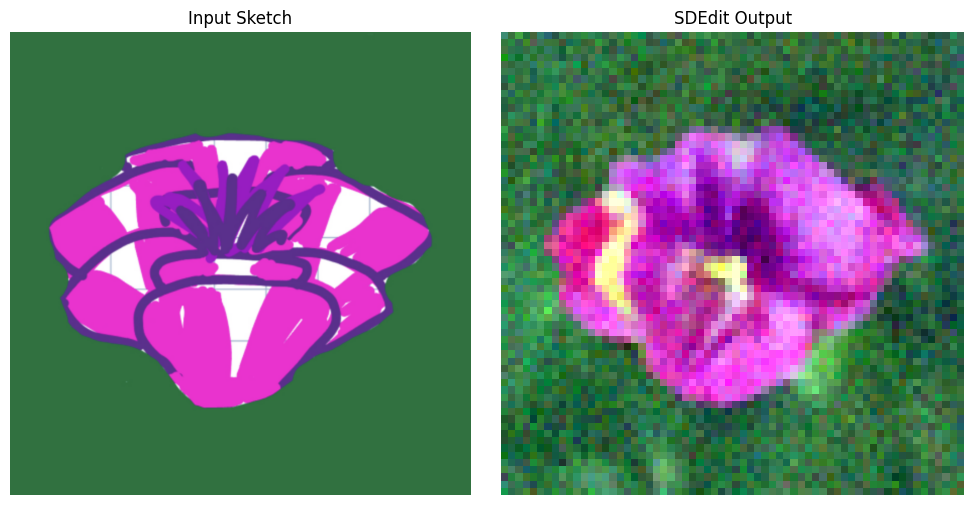

In [ ]:
os.listdir()

test_sketch_1 = "sketch.png"
test_1_output = "sde_output_1.png"

display_comparison(test_sketch_1, test_1_output)

In [ ]:
uploaded = files.upload()

Saving test_sketch_2.jpeg to test_sketch_2.jpeg


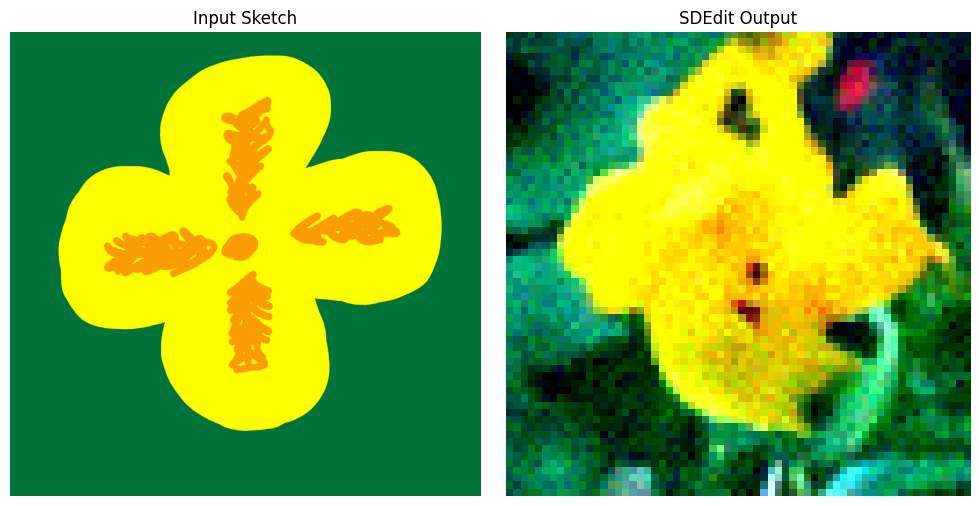

In [ ]:
run_sdedit_on_sketch("test_sketch_2.jpeg", model, "sde_output_2.png")

test_sketch_2 = "test_sketch_2.jpeg"
test_2_output = "sde_output_2.png"

display_comparison(test_sketch_2, test_2_output)

In [ ]:
def load_and_preprocess(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [image_size, image_size])
    img = tf.cast(img, tf.float32) / 127.5 - 1.0
    return img

def denormalize(img):
    return tf.clip_by_value((img + 1.0) / 2.0, 0.0, 1.0)

def plot_realism_vs_faithfulness(image_paths, t0_values, l2_scores, kid_scores, save_path=None):
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    import numpy as np

    def clean_nans(x, y):
        x = np.array(x)
        y = np.array(y)
        mask = ~np.isnan(y)
        return x[mask], y[mask]

    l2_squared = np.square(l2_scores)
    t0_kid, kid_clean = clean_nans(t0_values, kid_scores)
    t0_l2, l2_clean = clean_nans(t0_values, l2_squared)

    fig = plt.figure(figsize=(16, 6))

    ax1 = fig.add_subplot(2, 1, 1)
    ax1.plot(t0_kid, kid_clean, label="KID (Realism)", color="tab:blue", linewidth=2)
    ax1.set_ylabel("KID (Realism)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xlabel(r"$t_0$")
    ax1.set_ylim(0, max(kid_clean) * 1.2 if len(kid_clean) > 0 else 1.0)

    ax2 = ax1.twinx()
    ax2.plot(t0_l2, l2_clean, label=r"$L_2$ (Faithfulness)", color="darkorange", linewidth=2)
    ax2.set_ylabel(r"$L_2$ (Faithfulness)", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax2.set_ylim(0, max(l2_clean) * 1.2 if len(l2_clean) > 0 else 1.0)

    ax1.axvline(0.4, color="green", linestyle="--", alpha=0.5)
    ax1.axvline(0.6, color="green", linestyle="--", alpha=0.5)
    ax1.text(0.5, max(kid_clean) * 1.1 if len(kid_clean) > 0 else 0.5, "Sweet spot", ha="center", color="green")

    n = len(image_paths)
    for i, path in enumerate(image_paths):
        try:
            img = mpimg.imread(path)
        except:
            continue
        ax_img = fig.add_axes([0.05 + 0.9 * i / n, 0.15, 0.9 / n, 0.2])
        ax_img.imshow(img)
        ax_img.axis("off")
        ax_img.set_title(f"$t_0$={t0_values[i]:.1f}", fontsize=9)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def sdedit_sweet_spot(sketch_path, output_paths, ground_truth_path, t0_values, save_path=None):
    l2_list = []
    kid_list = []
    visual_paths = []

    sketch = load_and_preprocess(sketch_path)[None, ...]
    ground_truth = load_and_preprocess(ground_truth_path)[None, ...]
    ground_truth_dn = denormalize(ground_truth)

    for i, output_group in enumerate(output_paths):
        visual_paths.append(output_group[0])

        output_images = [load_and_preprocess(p)[None, ...] for p in output_group]
        output_batch = tf.concat(output_images, axis=0)
        output_batch_dn = denormalize(output_batch)


        l2_scores = [tf.reduce_mean(tf.square(sketch - out)).numpy() for out in output_images]
        l2_list.append(np.mean(l2_scores))

        real_batch = tf.concat([ground_truth_dn] * len(output_group), axis=0)
        kid_metric = KID(name=f"kid_t{i}")
        try:
            kid_metric.update_state(real_batch, output_batch_dn)
            kid = kid_metric.result().numpy()
            kid_list.append(kid)
        except:
            kid_list.append(np.nan)

    plot_realism_vs_faithfulness(visual_paths, t0_values, l2_list, kid_list, save_path=save_path)
    return {"t0": t0_values, "l2": l2_list, "kid": kid_list}


In [ ]:
## PINK FLOWER REALISM / FAITHFULNESS FIG ##
os.makedirs("outputs", exist_ok=True)
t0_vals = np.linspace(0.0, 0.9999, 10)
for sample in [1, 2, 3]:
  for i in range(0, 10):
    t_0 = t0_vals[i]
    pic_num = i + 1
    run_sdedit_on_sketch("pink_flower_sketch.jpg", model, f"outputs/sde_pink_flower_{pic_num}_sample{sample}.png", t_0=t_0)
    print(f'Sample {sample}, Img {pic_num} Finished')


In [ ]:
outputs_per_t0 = [
    [f"outputs/sde_pink_flower_{i+1}_sample{sample}.png" for sample in [1, 2, 3]]
    for i in range(10)
]

metrics = sdedit_sweet_spot(
    sketch_path="pink_flower_sketch.jpg",
    output_paths=outputs_per_t0,
    ground_truth_path="pink_flower_gt.png",
    t0_values=t0_vals,
    save_path="pink_flower_rf_plot.png"
)

In [ ]:
## SUNFLOWER REALISM / FAITHFULNESS FIG ##
os.makedirs("outputs", exist_ok=True)
t0_vals = np.linspace(0.0, 0.9999, 10)
for sample in [1, 2, 3]:
  for i in range(0, 10):
    t_0 = t0_vals[i]
    pic_num = i + 1
    run_sdedit_on_sketch("sunflower_sketch.png", model, f"outputs/sde_sunflower_{pic_num}_sample{sample}.png", t_0=t_0)
    print(f'Sample {sample}, Img {pic_num} Finished')

In [ ]:
outputs_per_t0 = [
    [f"outputs/sde_sunflower_{i+1}_sample{sample}.png" for sample in [1, 2, 3]]
    for i in range(10)
]

metrics = sdedit_sweet_spot(
    sketch_path="sunflower_sketch.png",
    output_paths=outputs_per_t0,
    ground_truth_path="sunflower_gt.png",
    t0_values=t0_vals,
    save_path="sunflower_rf_plot.png"
)